### **Yogyakarta's Air Quality Dataset in September 2021**

In [2]:
import pandas as pd

df = pd.read_csv("09-jogja-sep-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,9/1/2021,00:00:00,16.0,28.0,0.0,7.0,0.0,4.0,28,PM2.5,Good
2,9/1/2021,01:00:00,16.0,28.0,0.0,7.0,0.0,4.0,28,PM2.5,Good
3,9/1/2021,02:00:00,16.0,28.0,0.0,7.0,0.0,4.0,28,PM2.5,Good
4,9/1/2021,03:00:00,18.0,32.0,0.0,7.0,1.0,4.0,32,PM2.5,Good
5,9/1/2021,04:00:00,18.0,32.0,0.0,6.0,1.0,4.0,32,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
716,9/30/2021,19:00:00,19.0,35.0,0.0,7.0,4.0,4.0,35,PM2.5,Good
717,9/30/2021,20:00:00,19.0,35.0,0.0,7.0,4.0,4.0,35,PM2.5,Good
718,9/30/2021,21:00:00,19.0,36.0,0.0,7.0,5.0,4.0,36,PM2.5,Good
719,9/30/2021,22:00:00,20.0,36.0,0.0,7.0,5.0,4.0,36,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [3]:
filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 09-jogja-sep-2021.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    object 
 1   Time                720 non-null    object 
 2   PM10                719 non-null    float64
 3   PM2.5               719 non-null    float64
 4   SO2                 517 non-null    float64
 5   CO                  719 non-null    float64
 6   O3                  499 non-null    float64
 7   NO2                 719 non-null    float64
 8   Max                 720 non-null    int64  
 9   Critical Component  719 non-null    object 
 10  Category            720 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 62.0+ KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [4]:
filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 09-jogja-sep-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,719.000000,719.000000,517.000000,719.000000,499.000000,719.000000,720.000000
mean,15.425591,29.208623,9.684720,8.180807,12.611222,4.853964,31.756944
std,3.888733,6.673306,19.065554,1.838347,13.114003,1.504712,10.292824
min,8.000000,14.000000,0.000000,4.000000,0.000000,2.000000,0.000000
25%,12.000000,24.000000,0.000000,7.000000,2.000000,4.000000,24.000000
50%,16.000000,29.000000,1.000000,8.000000,8.000000,5.000000,30.000000
75%,19.000000,35.000000,5.000000,9.000000,20.000000,6.000000,37.000000
max,24.000000,44.000000,63.000000,14.000000,52.000000,8.000000,63.000000


##### <span style="color:blue">**1. Critical Component**</span>

In [6]:
filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 09-jogja-sep-2021.csv


Critical Component
PM2.5    86.509040
SO2      11.543811
O3        1.947149
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [7]:
filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 09-jogja-sep-2021.csv


Category
Good        92.638889
Moderate     7.361111
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 09-jogja-sep-2021.csv


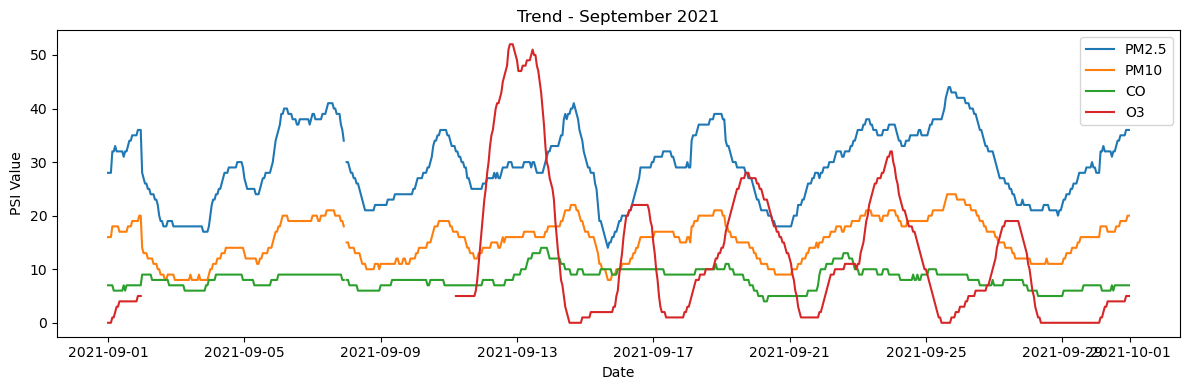

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the July data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - September 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 09-jogja-sep-2021.csv


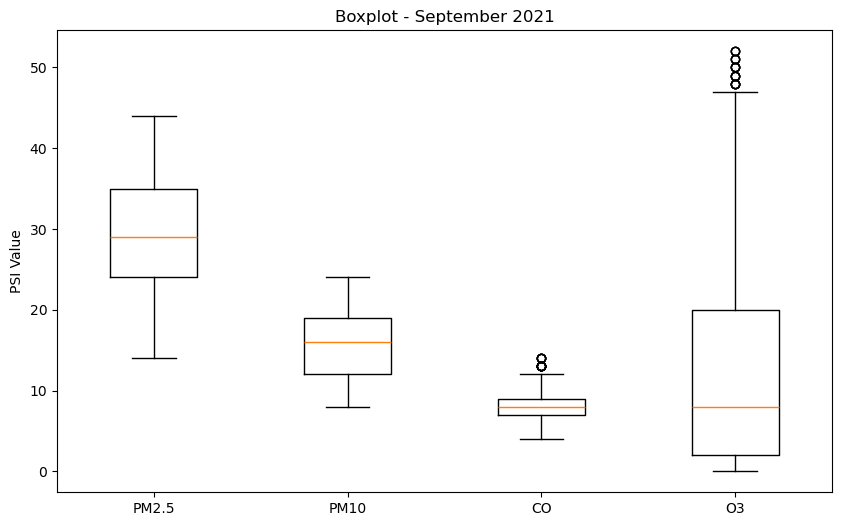

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - September 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 09-jogja-sep-2021.csv


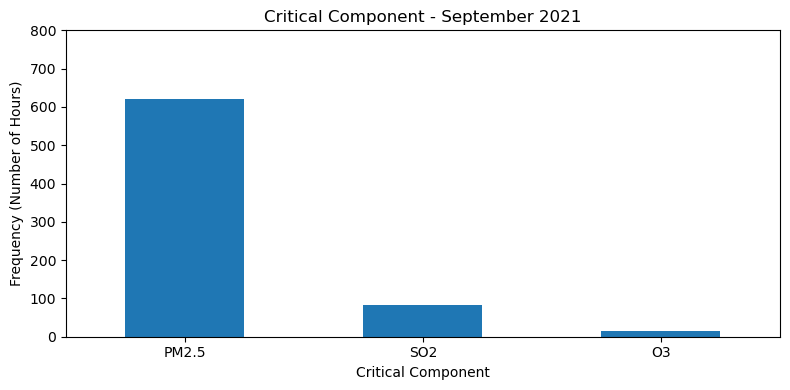

Critical Component
PM2.5    622
SO2       83
O3        14
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - September 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: 09-jogja-sep-2021.csv


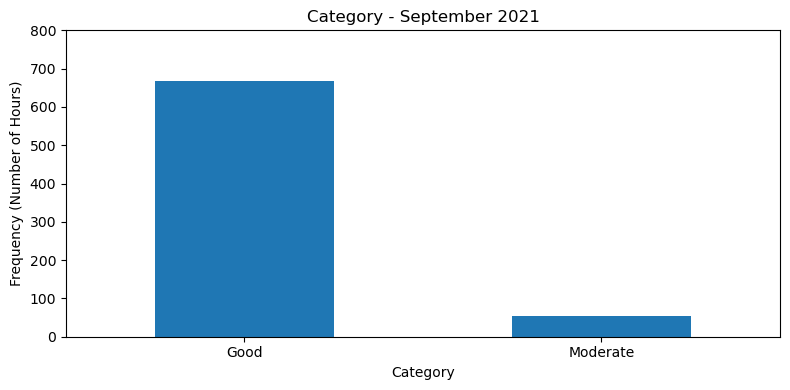

Category
Good        667
Moderate     53
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - September 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category